## Utility
### - 天体名対応辞書作成

In [458]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  

  # sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars_converted  = sources_blazars.strip().replace('4FGL ','').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # print(sources_blazars_selected_cls)
  # print(sources_blazars_cls[idx])
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])
  # print(sources_blazars_selected_cls_converted)  

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


### 使い方

In [459]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3c_454.3,FSRQ,1
j1104.4+3812,mkn_421,BLL,2


In [460]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3C454.3,FSRQ,1
j1104.4+3812,Mrk421,BLL,2
j2202.7+4216,BLLac,BLL,3
j2232.6+1143,CTA102,FSRQ,4
j1256.1-0547,3C279,FSRQ,5
j0721.9+7120,S50716+71,BLL,6
j1427.9-4206,PKS1424-41,FSRQ,7
j0428.6-3756,PKS0426-380,BLL,8
j0538.8-4405,PKS0537-441,BLL,9


In [461]:
def update_dict_sourcenames_for_drawing(dict_sourcename):
  # add the key 'assoc name for drawing' to dict_sourcename(astropy Table), which is used for drawing the SEDs.
  dict_sourcename['assoc name for drawing'] = ["not assigned"]*len(dict_sourcename)
  dict_sourcename[ 0]['assoc name for drawing']  = '3C 454.3' 
  dict_sourcename[ 1]['assoc name for drawing']  = 'Mrk 421' 
  dict_sourcename[ 2]['assoc name for drawing']  = 'BL Lac' 
  dict_sourcename[ 3]['assoc name for drawing']  = 'CTA 102' 
  dict_sourcename[ 4]['assoc name for drawing']  = '3C 279'
  dict_sourcename[ 5]['assoc name for drawing']  = 'S5 0716+71' 
  dict_sourcename[ 6]['assoc name for drawing']  = 'PKS 1424-41' 
  dict_sourcename[ 7]['assoc name for drawing']  = 'PKS 0426-380'
  dict_sourcename[ 8]['assoc name for drawing']  = 'PKS 0537-441'
  dict_sourcename[ 9]['assoc name for drawing']  = 'PKS 2155-304'
  dict_sourcename[10]['assoc name for drawing'] = 'PKS 0454-234'
  dict_sourcename[11]['assoc name for drawing'] = 'PKS 1510-089'
  dict_sourcename[12]['assoc name for drawing'] = 'PKS 1502+106'
  dict_sourcename[13]['assoc name for drawing'] = 'TON 599'
  dict_sourcename[14]['assoc name for drawing'] = 'PKS 0346-27'
  dict_sourcename[15]['assoc name for drawing'] = '4C +01.02'
  dict_sourcename[16]['assoc name for drawing'] = '4C +55.17'
  dict_sourcename[17]['assoc name for drawing'] = '4C +21.35'
  dict_sourcename[18]['assoc name for drawing'] = 'PKS 1830-211'
  dict_sourcename[19]['assoc name for drawing'] = 'PKS 0208-512'
  dict_sourcename[0:15]
  return dict_sourcename


### 赤方偏辞書作成 (1)

https://iopscience.iop.org/0067-0049/253/2/46/suppdata/apjsabe135t9_ascii.txt?doi=10.3847/1538-4365/abe135

From the article, Paliya+21 
"The Central Engines of Fermi Blazars"
https://iopscience.iop.org/article/10.3847/1538-4365/abe135#apjsabe135t10


In [462]:

import numpy as np
from astropy.table import Table
def get_dict_redshift():
  tab = Table.read('./catalogs/apjsabe135t9_ascii_edited.txt',format='ascii')
  return tab
  

### 使い方

In [463]:
dict_redshift = get_dict_redshift()
print(dict_redshift[0:5])

 4FGL name   Redshift M_BH M_BH_error
------------ -------- ---- ----------
J0037.8+1239    0.089 8.64       0.14
J0050.7-0929    0.635 8.85       0.18
J0109.1+1815    0.145 9.09       0.23
J0123.1+3421    0.272 8.68       0.14
J0159.5+1046    0.195 8.51       0.14


In [464]:
# add redshift to dict_sourcename, searching from dict_redshift
for i in range(len(dict_sourcename)):
  source_4FGL = dict_sourcename[i]['4FGL name'].upper()
  source_assoc = dict_sourcename[i]['assoc name']
  print(f"Searching for {source_4FGL}, {source_assoc}")
  mask = (dict_redshift['4FGL name'] == source_4FGL.lower())
  print(mask)
  # if len(match) == 0:
  #   match = dict_redshift[dict_redshift['Source name'].str.strip().replace(' ','').lower() == source_assoc.replace(' ','').lower()]
  # if len(match) == 0:
  #   print(f"Not found: {source_4FGL}, {source_assoc}")
  #   dict_sourcename[i]['redshift'] = np.
  # elif len(match) > 1:
  #   print(f"Multiple matches found for {source_4FGL}, {source_assoc}:")
  #   print(match)
  #   dict_sourcename[i]['redshift'] = match[0]['Redshift']
  # else:
  #   dict_sourcename[i]['redshift'] = match[0]['Redshift']



Searching for J2253.9+1609, 3C454.3
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J1104.4+3812, Mrk421
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J2202.7+4216, BLLac
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False]
Searching for J2232.6+1143, CTA102

### 赤方偏辞書作成 (2)

https://iopscience.iop.org/1538-3881/168/6/289/suppdata/ajad8231t1_ascii.txt?doi=10.3847/1538-3881/ad8231

From article N. Sahakyan+24
"Markarian Multiwavelength Data Center (MMDC): A Tool for Retrieving and Modeling Multitemporal, Multiwavelength, and Multimessenger Data from Blazar Observations"
https://iopscience.iop.org/article/10.3847/1538-3881/ad8231


In [465]:
import numpy as np
from astropy.table import Table
def get_dict_redshift():
  tab = Table.read('./catalogs/ajad8231t1_ascii_edited.txt',delimiter=',', header_start=0,data_start=1, format='ascii')
  return tab

In [466]:
dict_redshift = get_dict_redshift()
print(dict_redshift[0:5])

Source name   4FGL name   Source Class SED Class  R.A.  Decl. Redshift col7
------------ ------------ ------------ --------- ------ ----- -------- ----
    3C 454.3 J2253.9+1609         FSRQ       LSP  343.5 16.15     0.86   --
      3C 279 J1256.1-0547         FSRQ       LSP 194.04 -5.79     0.54   --
     CTA 102 J2232.6+1143         FSRQ       LSP 338.15 11.73     1.04   --
     Mkn 421 J1104.4+3812          BLL       HSP 166.12 38.21     0.03   --
PKS 1510-089 J1512.8-0906         FSRQ       LSP 228.21 -9.11     0.36   --


In [467]:
# add redshift to dict_sourcename, searching from dict_redshift
dict_sourcename['redshift'] = np.nan
for i in range(len(dict_sourcename)):
  source_4FGL = dict_sourcename[i]['4FGL name'].upper().replace(' ','')
  source_assoc = dict_sourcename[i]['assoc name']
  # print(f"Searching for {source_4FGL}, {source_assoc}")
  mask = (dict_redshift['4FGL name'] == source_4FGL)
  # print(mask, np.sum(mask))
  if np.sum(mask) > 0:
    dict_sourcename[i]['redshift'] = dict_redshift['Redshift'][mask]

print(dict_sourcename[0:20])


 4FGL name    assoc name CLASS index redshift
------------ ----------- ----- ----- --------
j2253.9+1609     3C454.3  FSRQ     1     0.86
j1104.4+3812      Mrk421   BLL     2     0.03
j2202.7+4216       BLLac   BLL     3     0.07
j2232.6+1143      CTA102  FSRQ     4     1.04
j1256.1-0547       3C279  FSRQ     5     0.54
j0721.9+7120   S50716+71   BLL     6     0.13
j1427.9-4206  PKS1424-41  FSRQ     7     1.52
j0428.6-3756 PKS0426-380   BLL     8     1.11
j0538.8-4405 PKS0537-441   BLL     9    0.896
j2158.8-3013 PKS2155-304   BLL    10     0.12
j0457.0-2324 PKS0454-234  FSRQ    11      1.0
j1512.8-0906 PKS1510-089  FSRQ    12     0.36
j1504.4+1029 PKS1502+106  FSRQ    13     1.84
j1159.5+2914      TON599  FSRQ    14   0.7247
j0348.6-2749  PKS0346-27  FSRQ    15    0.991
j0108.6+0134    4c+01.02  FSRQ    16    2.099
j0957.6+5523    4c+55.17  FSRQ    17   0.8955
j1224.9+2122    4c+21.35  FSRQ    18     0.43
j1833.6-2103 PKS1830-211  FSRQ    19    2.507
j0210.7-5101 PKS0208-512  FSRQ    

In [468]:
print(dict_sourcename[0:20])

 4FGL name    assoc name CLASS index redshift
------------ ----------- ----- ----- --------
j2253.9+1609     3C454.3  FSRQ     1     0.86
j1104.4+3812      Mrk421   BLL     2     0.03
j2202.7+4216       BLLac   BLL     3     0.07
j2232.6+1143      CTA102  FSRQ     4     1.04
j1256.1-0547       3C279  FSRQ     5     0.54
j0721.9+7120   S50716+71   BLL     6     0.13
j1427.9-4206  PKS1424-41  FSRQ     7     1.52
j0428.6-3756 PKS0426-380   BLL     8     1.11
j0538.8-4405 PKS0537-441   BLL     9    0.896
j2158.8-3013 PKS2155-304   BLL    10     0.12
j0457.0-2324 PKS0454-234  FSRQ    11      1.0
j1512.8-0906 PKS1510-089  FSRQ    12     0.36
j1504.4+1029 PKS1502+106  FSRQ    13     1.84
j1159.5+2914      TON599  FSRQ    14   0.7247
j0348.6-2749  PKS0346-27  FSRQ    15    0.991
j0108.6+0134    4c+01.02  FSRQ    16    2.099
j0957.6+5523    4c+55.17  FSRQ    17   0.8955
j1224.9+2122    4c+21.35  FSRQ    18     0.43
j1833.6-2103 PKS1830-211  FSRQ    19    2.507
j0210.7-5101 PKS0208-512  FSRQ    


## - Utility functions


### Probability table generation

14 bins from 9 to 22


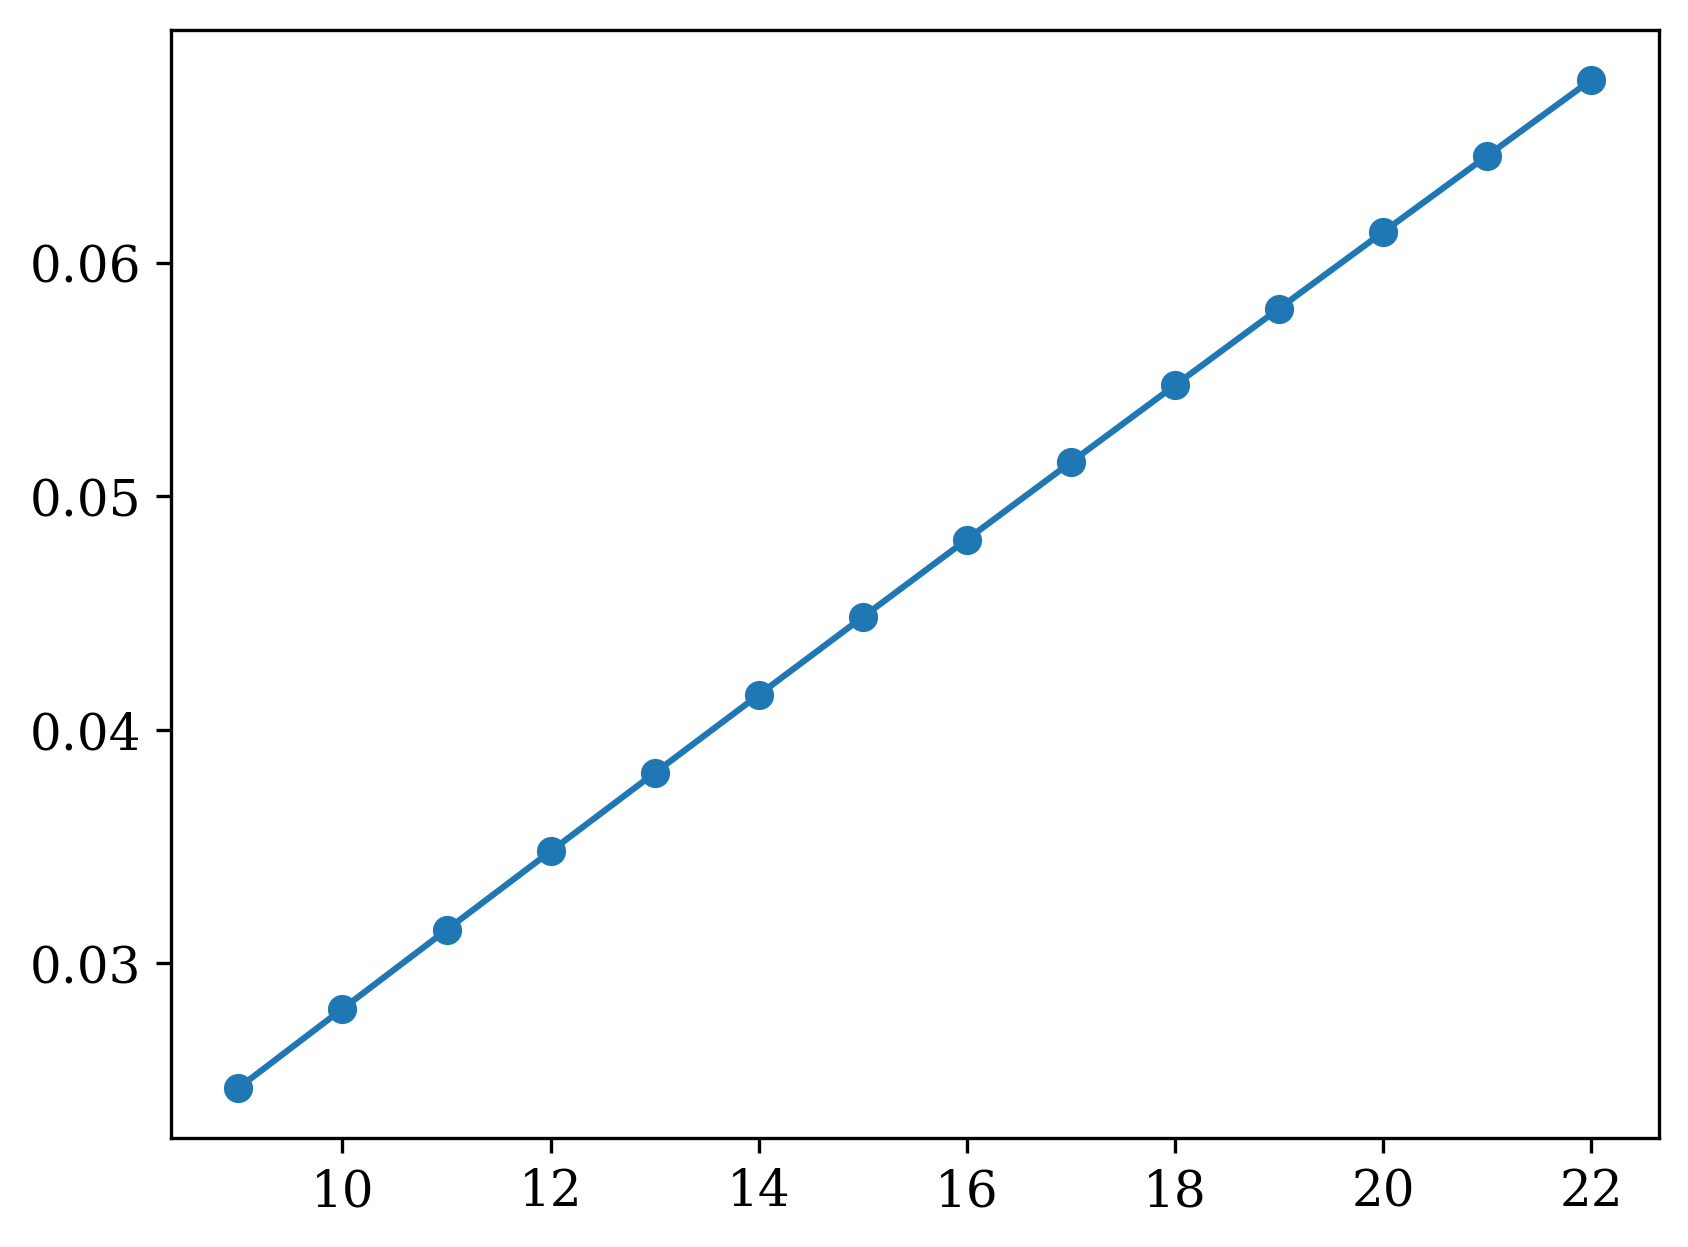

In [469]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

### Peak detection
### Gaussian
### Red.Chisq. calculation
### Confidence interval (of k/N) calculation

In [470]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit
from scipy.stats import chi2, norm

###################
# Peak detection
###################
nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1.0):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

###################
# Peak detection, improved
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  # significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths#,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        # significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths#,significances
###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)




################################################
### # Confidence interval calculation - not used yet
### 
### 
### 
#################################################
from scipy.stats import beta
import numpy as np
def calc_ci_ClopperPearson(k=20, n=400, alpha=0.32):
  # k = 20
  # n = 400
  # alpha = 0.05
  p_l, p_u = beta.ppf([alpha / 2, 1 - alpha / 2], [k, k + 1], [n - k + 1, n - k])
  if np.isnan(p_u):
      p_u = 1
  if np.isnan(p_l):
      p_l = 0
  return p_l, p_u




### plotSED

In [471]:
def plotSED_erg_GeV_forAandA(x, y, yerr, fitted_line, 
                             peakinitbins, peaklengths, residuals,reduced_chi_squared, 
                             obsdate, sourcename='',sourcenameheader='',
                             sourcenamefordrawing="",figlabel='(a)',leg_loc='best'):
  # For fig.5 in A&A two-column style
  # A&A double column width: 17.4 cm ~ 6.85 in
  plt.rcParams.update({
      'font.family': 'serif',
      'font.size': 14, #10,
      'axes.labelsize': 12, #10,
      'axes.titlesize': 12, #10,
      'xtick.labelsize': 12, #8,
      'ytick.labelsize': 12, #8,
      'legend.fontsize': 10, #8,
      'figure.dpi': 300,
      'mathtext.fontset': 'stix',
  })  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10*0.7, 6*0.7))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', color='tab:blue', label='Fitted LP model')
  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='NF Region', marker='x', linestyle='-')
  # plt.title(f"{sourcenamefordrawing} : MJD={round(obsdate,3)}, "+ r"$\chi^2$/ndf=" +f"{reduced_chi_squared:.2f}")
  plt.title(f"{sourcenamefordrawing}, "+ r"$\chi^2$/ndf=" +f"{reduced_chi_squared:.2f}")
  # plt.title(r"$\chi^2$/ndf=" +f"{reduced_chi_squared:.2f}")
  ## add figlabel (like text (a), (b), (c), ...) at the top left corner of the plot
  plt.text(0.02, 0.95, figlabel, transform=plt.gca().transAxes, fontsize=15, verticalalignment='top') 
    
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # delete xaxis tick labels
  plt.gca().set_xticklabels([])
  # if the first data point is higher than 0.5 the high-edge of ylim, update the high-edge of ylim to be 3 times the first data point,
  # (low-edge of ylim is kept unchanged)
  if y[0] > 0.5 * plt.ylim()[1]:
    plt.ylim(plt.ylim()[0], y[0]*2)  
  plt.legend(loc=leg_loc,framealpha=0.5)

  frame1.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='grey', linestyle='--', label='Zero Line', alpha=0.7)
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  # y scale to be symmetric around zero, with some margin
  max_residual = np.max(np.abs(residuals))
  plt.ylim(-max_residual*1.1, max_residual*1.1)
  frame2.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

  plt.tight_layout()

  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_MJD{round(obsdate)}.png", dpi=300, bbox_inches='tight')
  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_MJD{round(obsdate)}.pdf", dpi=300, bbox_inches='tight')


### plotSED (refit)
ピーク領域除外フィット、SEDquest5.ipynbから複製、編集

In [472]:

# def plotSED_peakExcludedFit_erg_GeV(
#             X, Y, YERR, fitted_line,  fitted_line2, peakinitbins, peaklengths, 
#             fitexcludeinitbin,fitexcludelength, 
#             residuals,reduced_chi_squared, 
#             obsdate, idx, sourcename='',sourcenameheader=''
#             ):



def plotSED_erg_GeV_forAandA_peakExcludedFit(
          X, Y, YERR, fitted_line, fitted_line2, peakinitbins, peaklengths,
          fitexcludeinitbin,fitexcludelength, 
          residuals, reduced_chi_squared, 
          obsdate, sourcename, sourcenameheader,
          sourcenamefordrawing,figlabel, leg_loc):
  # For fig.5 in A&A two-column style
  # A&A double column width: 17.4 cm ~ 6.85 in
  plt.rcParams.update({
      'font.family': 'serif',
      'font.size': 14, #10,
      'axes.labelsize': 12, #10,
      'axes.titlesize': 12, #10,
      'xtick.labelsize': 12, #8,
      'ytick.labelsize': 12, #8,
      'legend.fontsize': 10, #8,
      'figure.dpi': 300,
      'mathtext.fontset': 'stix',
  })  


  y_scalefactor= (Y.to(u.Unit("erg cm-2 s-1")).value/Y.value)[0]
  model_y  = fitted_line(X) * y_scalefactor
  model2_y = fitted_line2(X) * y_scalefactor
  
  x = X.to(u.GeV).value  
  y = Y.to(u.Unit("erg cm-2 s-1")).value
  yerr = YERR.to(u.Unit("erg cm-2 s-1")).value
  
  
  # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10*0.7, 6*0.7))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', color='tab:gray',alpha=0.5, label='Fitted LP model (with NF)')
  if (fitexcludeinitbin>0):
    plt.plot(x[0:fitexcludeinitbin], model2_y[0:fitexcludeinitbin], '-', color='tab:blue', label='Fitted LP model (NF excluded)')
  plt.plot(x[fitexcludeinitbin-1: fitexcludeinitbin+fitexcludelength+1], model2_y[fitexcludeinitbin-1: fitexcludeinitbin+fitexcludelength+1], '--', color='tab:blue', label='Excluded from fitting')
  if (fitexcludeinitbin + fitexcludelength +1 < len(x)):
    plt.plot(x[fitexcludeinitbin + fitexcludelength :], model2_y[fitexcludeinitbin + fitexcludelength:], '-', color='tab:blue')

  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='NF Region', marker='x', linestyle='-',color='tab:orange')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcenamefordrawing}, "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  ## add figlabel (like text (a), (b), (c), ...) at the top left corner of the plot
  plt.text(0.02, 0.95, figlabel, transform=plt.gca().transAxes, fontsize=15, verticalalignment='top') 
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # delete xaxis tick labels
  plt.gca().set_xticklabels([])
  # if the first data point is higher than 0.5 the high-edge of ylim, update the high-edge of ylim to be 3 times the first data point,
  # (low-edge of ylim is kept unchanged)
  if y[0] > 0.5 * plt.ylim()[1]:
    plt.ylim(plt.ylim()[0], y[0]*2)  
  plt.legend(loc=leg_loc,framealpha=0.5)
  


  frame1.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='grey', linestyle='--', label='Zero Line', alpha=0.7)
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  # y scale to be symmetric around zero, with some margin
  max_residual = np.max(np.abs(residuals))
  plt.ylim(-max_residual*1.1, max_residual*1.1)
  frame2.grid(True, which='both', axis='both', linestyle='--', alpha=0.3)
  plt.tight_layout()
  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_MJD{round(obsdate)}_refit.png", dpi=300, bbox_inches='tight')
  plt.savefig(f"figures/{sourcenameheader}SED_AandA_{sourcename}_MJD{round(obsdate)}_refit.pdf", dpi=300, bbox_inches='tight')



# 主関数

In [473]:

###################
# Main function
###################
def draw_SED(filepath,target_MJD, range_days,
                 suffix='',sourcename='',sourcenamefordrawing='', figlabelA='(a)', figlabelB='(b)', leg_loc='best'): #'data/3C454.3_allsed_14d_min11.ecsv'

  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'

  if sourcename == '':
    sourcename = filepath.split('_')[0]
    sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  for obsdate in obsdates:
    if obsdate < target_MJD - range_days or obsdate > target_MJD + range_days:
      continue

    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue

    ### fit the data  ###
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    # array_chisq.append(reduced_chi_squared)
    
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    peakinitbins, peaklengths = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    
    if len(peakinitbins) > 0:
      # print('peakbininit',peakbininit)
      n_detected_peaks += len(peakinitbins)
      plotSED_erg_GeV_forAandA(x, y , yerr, fitted_line, 
                               peakinitbins, peaklengths, residuals, reduced_chi_squared, 
                               obsdate, sourcename, sourcenameheader,
                               sourcenamefordrawing,figlabelA, leg_loc)
      
      ### Taken from SEDquest5.ipynb ####
      # if len(peakinitbins) > 0:
      print('get_consecutive_bins_for_multi_peaks')
      # n_detected_peaks += 1
      print('***** Detected ', len(peakinitbins), ' peaks in the SED for ', sourcename, ' at MJD ', obsdate)
      for i_peak in range(len(peakinitbins)):
        print('  Peak #', i_peak+1, ': Found peak at bin:',peakinitbins[i_peak], 'length ', peaklengths[i_peak], 'in total length of ', len(residuals), 'p-value, sigma:')#, significances[i_peak])
        
        # refit without the peak region and see the significance of the peak again
        mask_nopk = np.ones(len(x), dtype=bool)
        mask_nopk[peakinitbins[i_peak]:peakinitbins[i_peak]+peaklengths[i_peak]] = False
        # if np.sum(mask_nopk) < nbinsmin:
        #   print('  Too few points to refit without the peak region')
        #   continue
        fitted_line2 = fit(logpar_init, x[mask_nopk],y[mask_nopk],weights=1.0/yerr[mask_nopk], maxiter=200)
        reduced_chi_squared2 = calc_reduced_chi_square(fitted_line2(x[mask_nopk]), x[mask_nopk],y[mask_nopk], yerr[mask_nopk], len(x), 4)
        if reduced_chi_squared2 > 4.0:
          # refit with another beta 
          logpar_init.beta.value = 0.1
          fitted_line2 = fit(logpar_init, x[mask_nopk],y[mask_nopk],weights=1.0/yerr[mask_nopk], maxiter=200)
          reduced_chi_squared2 = calc_reduced_chi_square(fitted_line2(x), x[mask_nopk],y[mask_nopk], yerr[mask_nopk], len(x), 4)  

        residuals2 = (y-fitted_line2(x))/yerr
        # peakinitbins2,peaklengths2,significances2 = get_consecutive_bins_for_multi_peaks(residuals2,nconsecutive)
        peakinitbins2,peaklengths2 = get_consecutive_bins_for_multi_peaks(residuals2,nconsecutive)        
        i_peak2_save = -1
        if len(peakinitbins2) > 0:
          print('  After refitting without the peak region, Detected ', len(peakinitbins2), ' peaks in the SED for ', sourcename, ' at MJD ', obsdate)
          for i_peak2 in range(len(peakinitbins2)):
            print('    Peak #', i_peak2+1, ': Found peak at bin:',peakinitbins2[i_peak2], 'length ', peaklengths2[i_peak2], 'in total length of ', len(residuals2), 'p-value, sigma:')#, significances2[i_peak2])
            if x[peakinitbins[i_peak]]*0.5 < x[peakinitbins2[i_peak2]] or x[peakinitbins[i_peak]]*1.5 > x[peakinitbins2[i_peak2]]  :
              i_peak2_save = i_peak2
          plotSED_erg_GeV_forAandA_peakExcludedFit(
                      x, y , yerr, fitted_line, fitted_line2, peakinitbins2, peaklengths2,
                      peakinitbins[i_peak], peaklengths[i_peak], 
                      residuals2, reduced_chi_squared2, 
                      obsdate, sourcename, sourcenameheader,
                      sourcenamefordrawing,figlabelB, leg_loc)
          
          # def plotSED_erg_GeV_forAandA_peakExcludedFit(
          #           X, Y, YERR, fitted_line,
          #           fitted_line2, peakinitbins2, peaklengths2,
          #           peakinitbins, peaklengths, fitexcludeinitbin,fitexcludelength, 
          #           residuals, reduced_chi_squared, 
          #           obsdate, sourcename, sourcenameheader,
          #           sourcenamefordrawing,figlabel, leg_loc):
                  
          # plotSED_peakExcludedFit_erg_GeV(x, y , yerr, fitted_line, fitted_line2, peakinitbins2, peaklengths2,
          #                                 peakinitbins[i_peak], peaklengths[i_peak], residuals2, reduced_chi_squared, obsdate, idx,sourcename,sourcenameheader)
# def plotSED_peakExcludedFit_erg_GeV(x, y, yerr, fitted_line, peakinitbins, peaklengths, 
                                    # fitexcludeinitbin,fitexcludelength, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
        else:
          print('  After refitting without the peak region, No significant peak found')


  print('-- Summary --')
  print('Source name:', sourcename)
  print('Number of detected peaks:',n_detected_peaks)
  

# 実行

index  assoc name targetMJD labelA labelB  leg_loc  
----- ----------- --------- ------ ------ ----------
    7 PKS0426-380   57552.0    (a)    (d) lower left
PKS0426-380


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_37731/1464790366.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  PKS0426-380  at MJD  57552.65603222185
  Peak # 1 : Found peak at bin: 11 length  4 in total length of  15 p-value, sigma:
  After refitting without the peak region, Detected  1  peaks in the SED for  PKS0426-380  at MJD  57552.65603222185
    Peak # 1 : Found peak at bin: 11 length  4 in total length of  15 p-value, sigma:


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_37731/1897722356.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


-- Summary --
Source name: PKS0426-380
Number of detected peaks: 1
index assoc name targetMJD labelA labelB  leg_loc  
----- ---------- --------- ------ ------ ----------
    3     CTA102   57398.0    (b)    (e) lower left
CTA102


...

-- Summary --
Source name: CTA102
Number of detected peaks: 1
index assoc name targetMJD labelA labelB   leg_loc   
----- ---------- --------- ------ ------ ------------
    1     Mrk421   59120.0    (c)    (f) upper center
Mrk421


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_37731/1464790366.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  Mrk421  at MJD  59120.65603222185
  Peak # 1 : Found peak at bin: 4 length  3 in total length of  22 p-value, sigma:
  After refitting without the peak region, Detected  1  peaks in the SED for  Mrk421  at MJD  59120.65603222185
    Peak # 1 : Found peak at bin: 4 length  3 in total length of  22 p-value, sigma:


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_37731/1897722356.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


-- Summary --
Source name: Mrk421
Number of detected peaks: 1


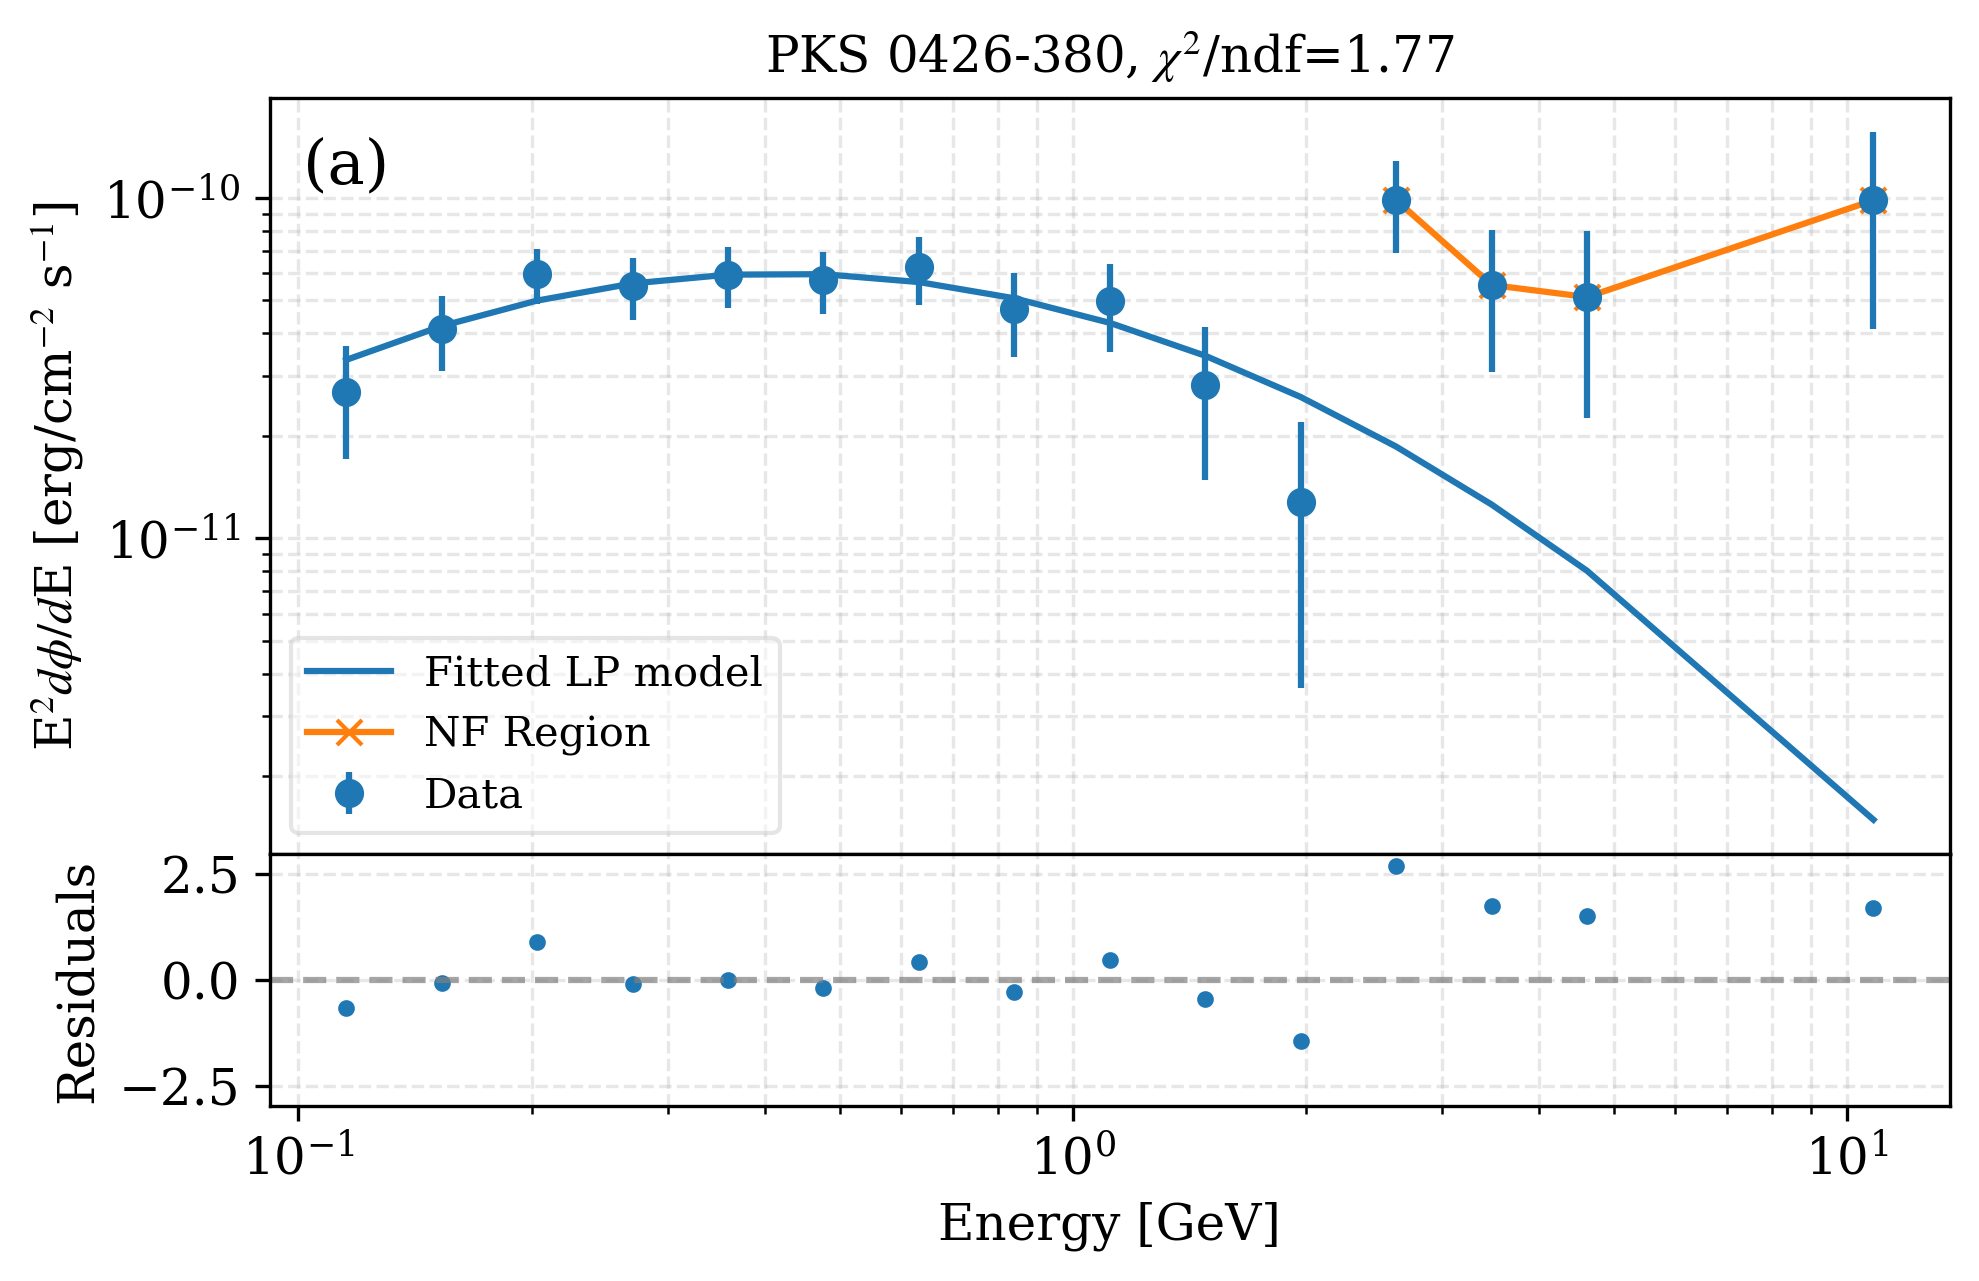

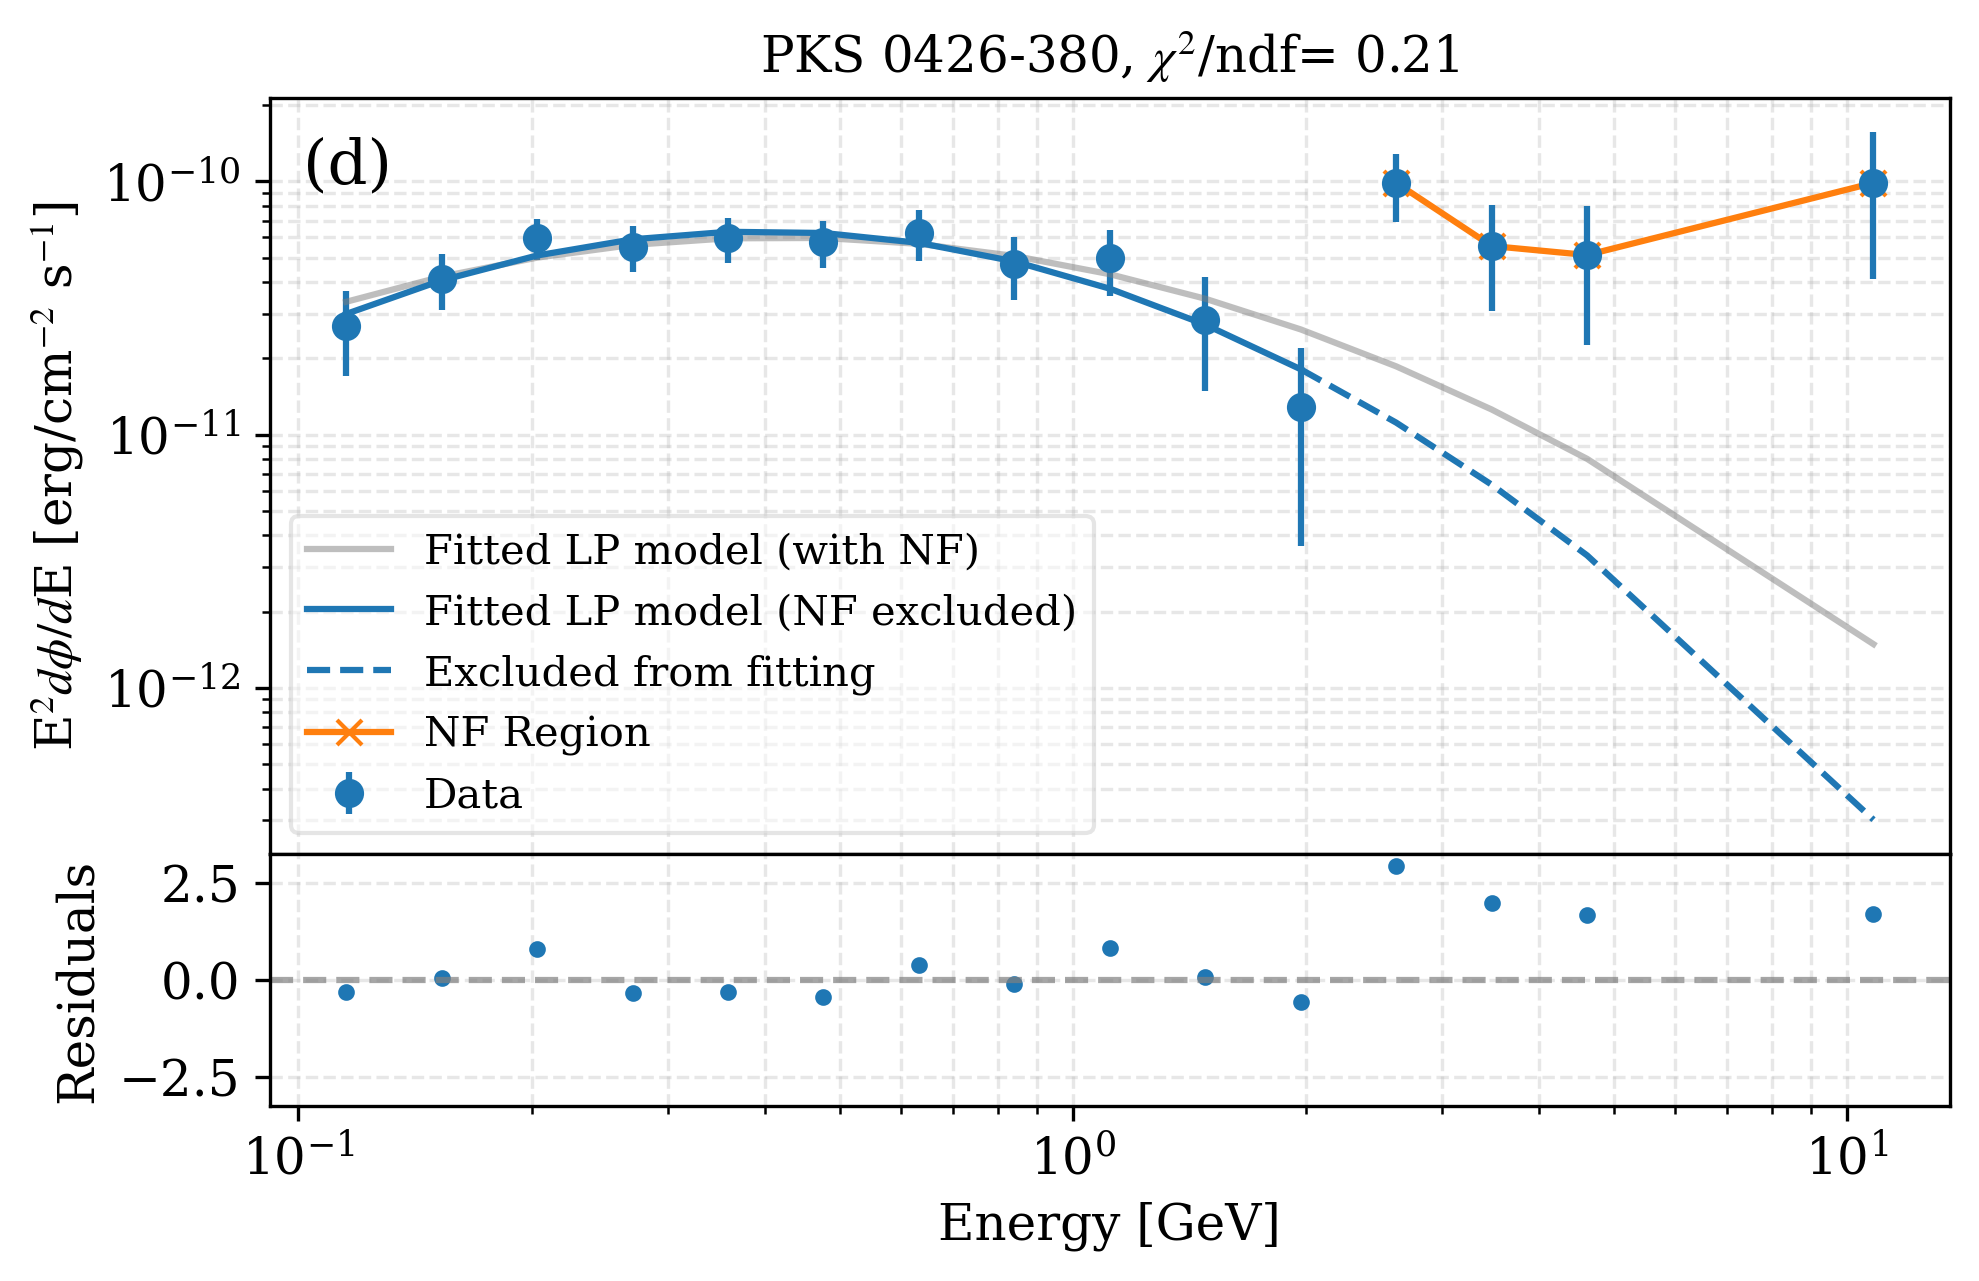

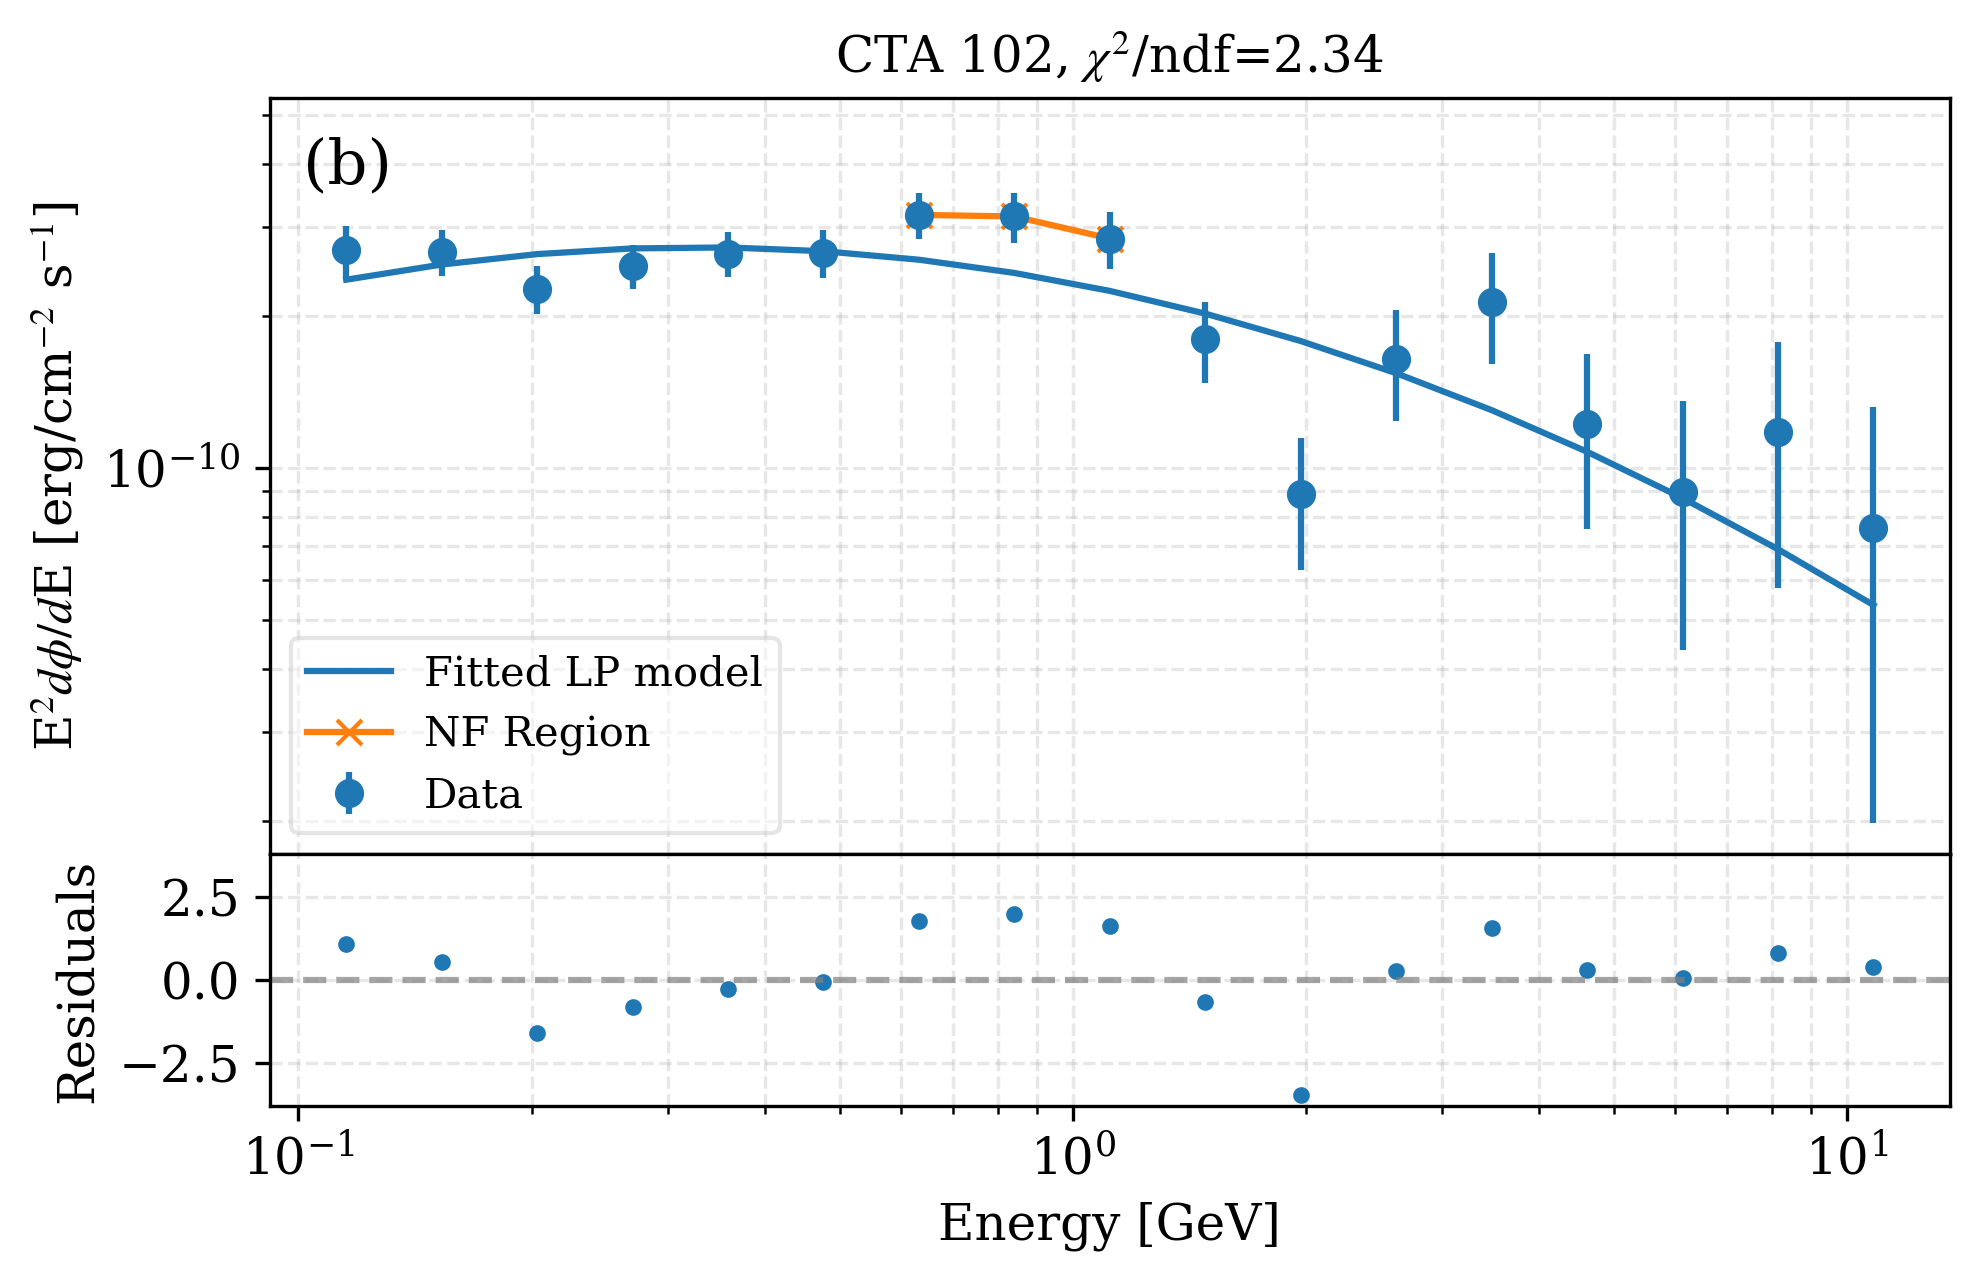

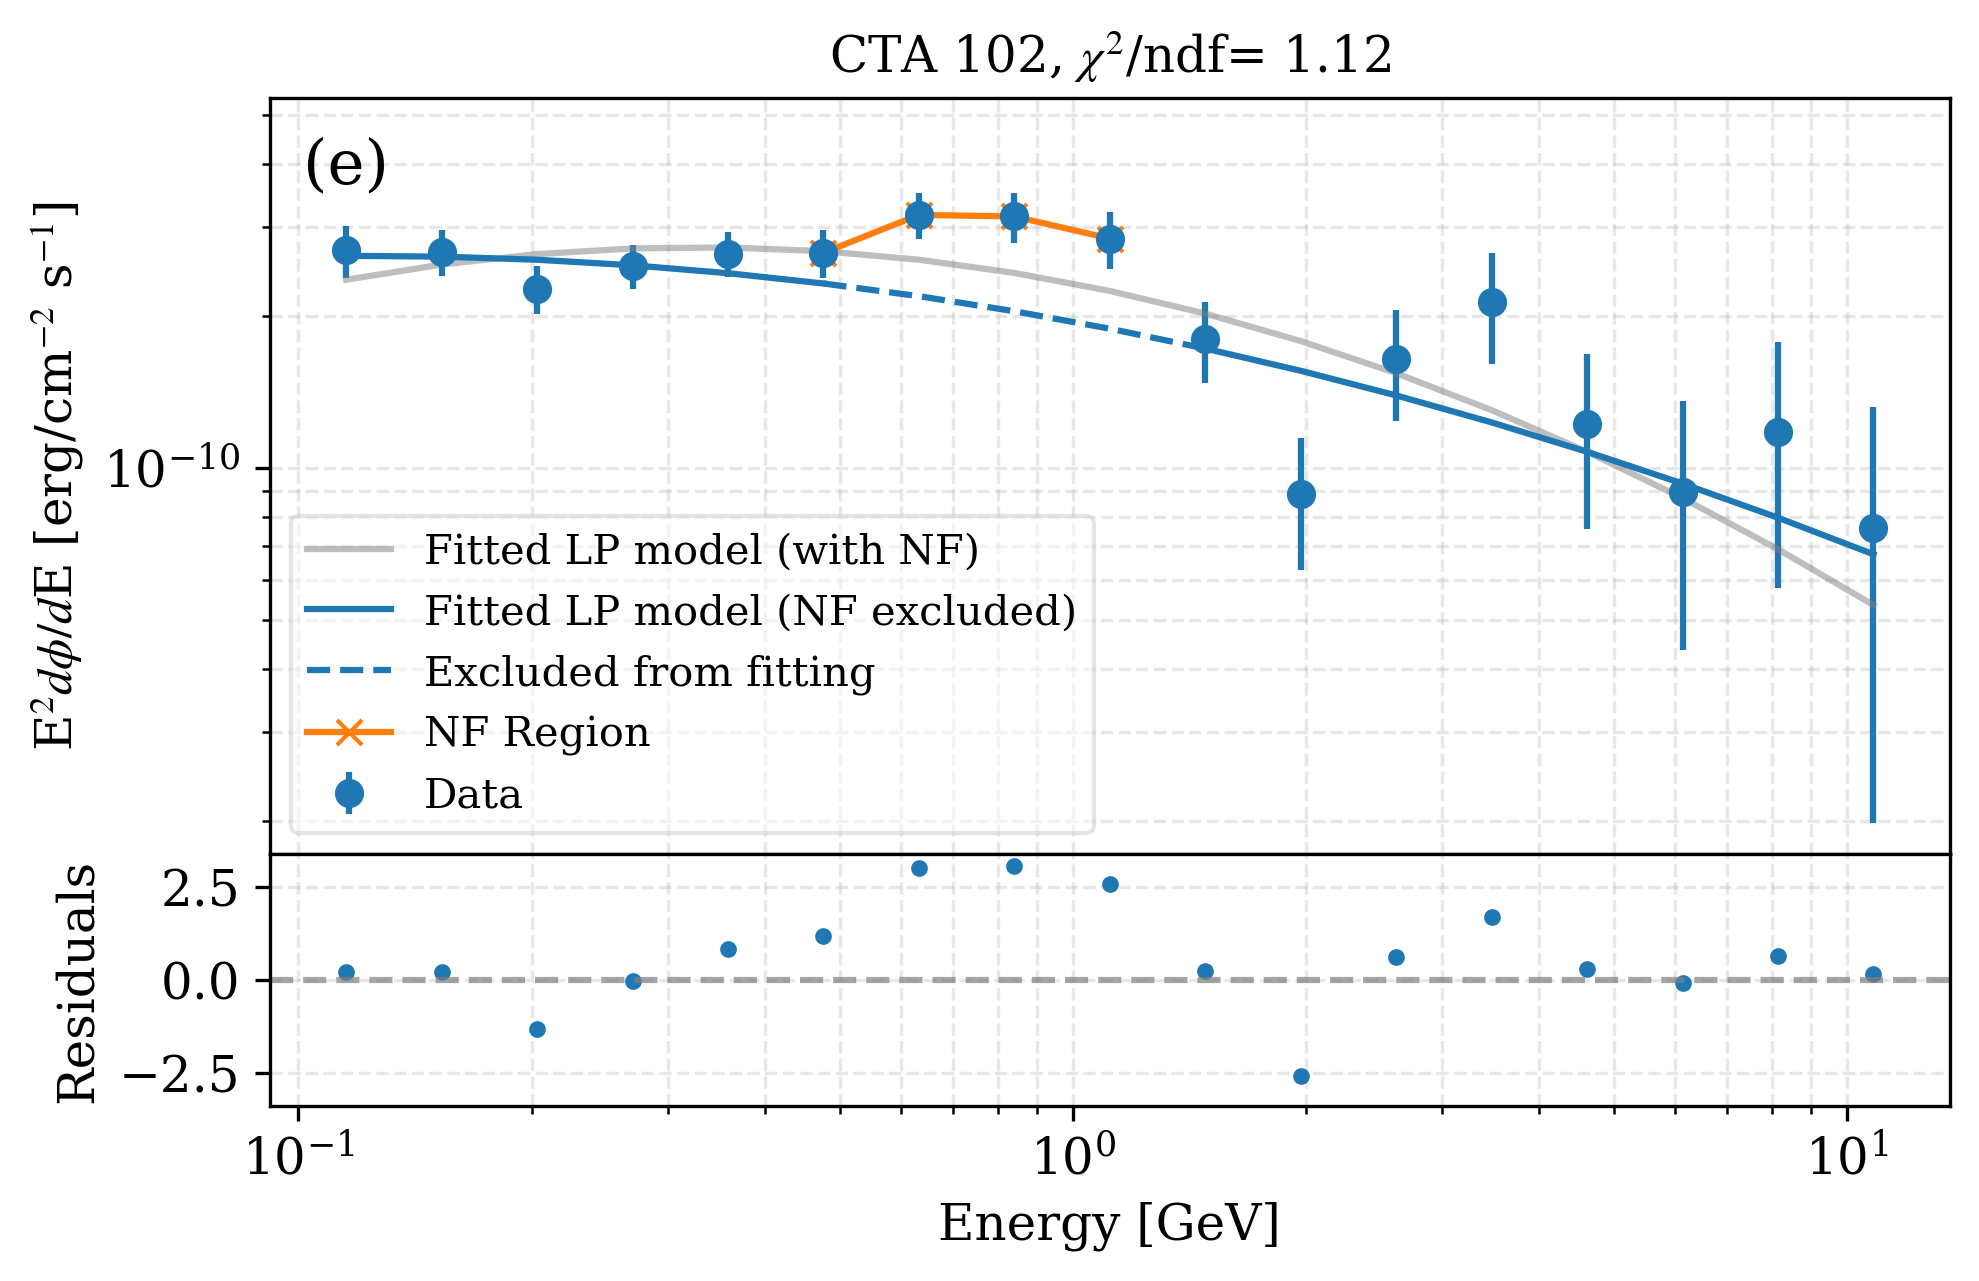

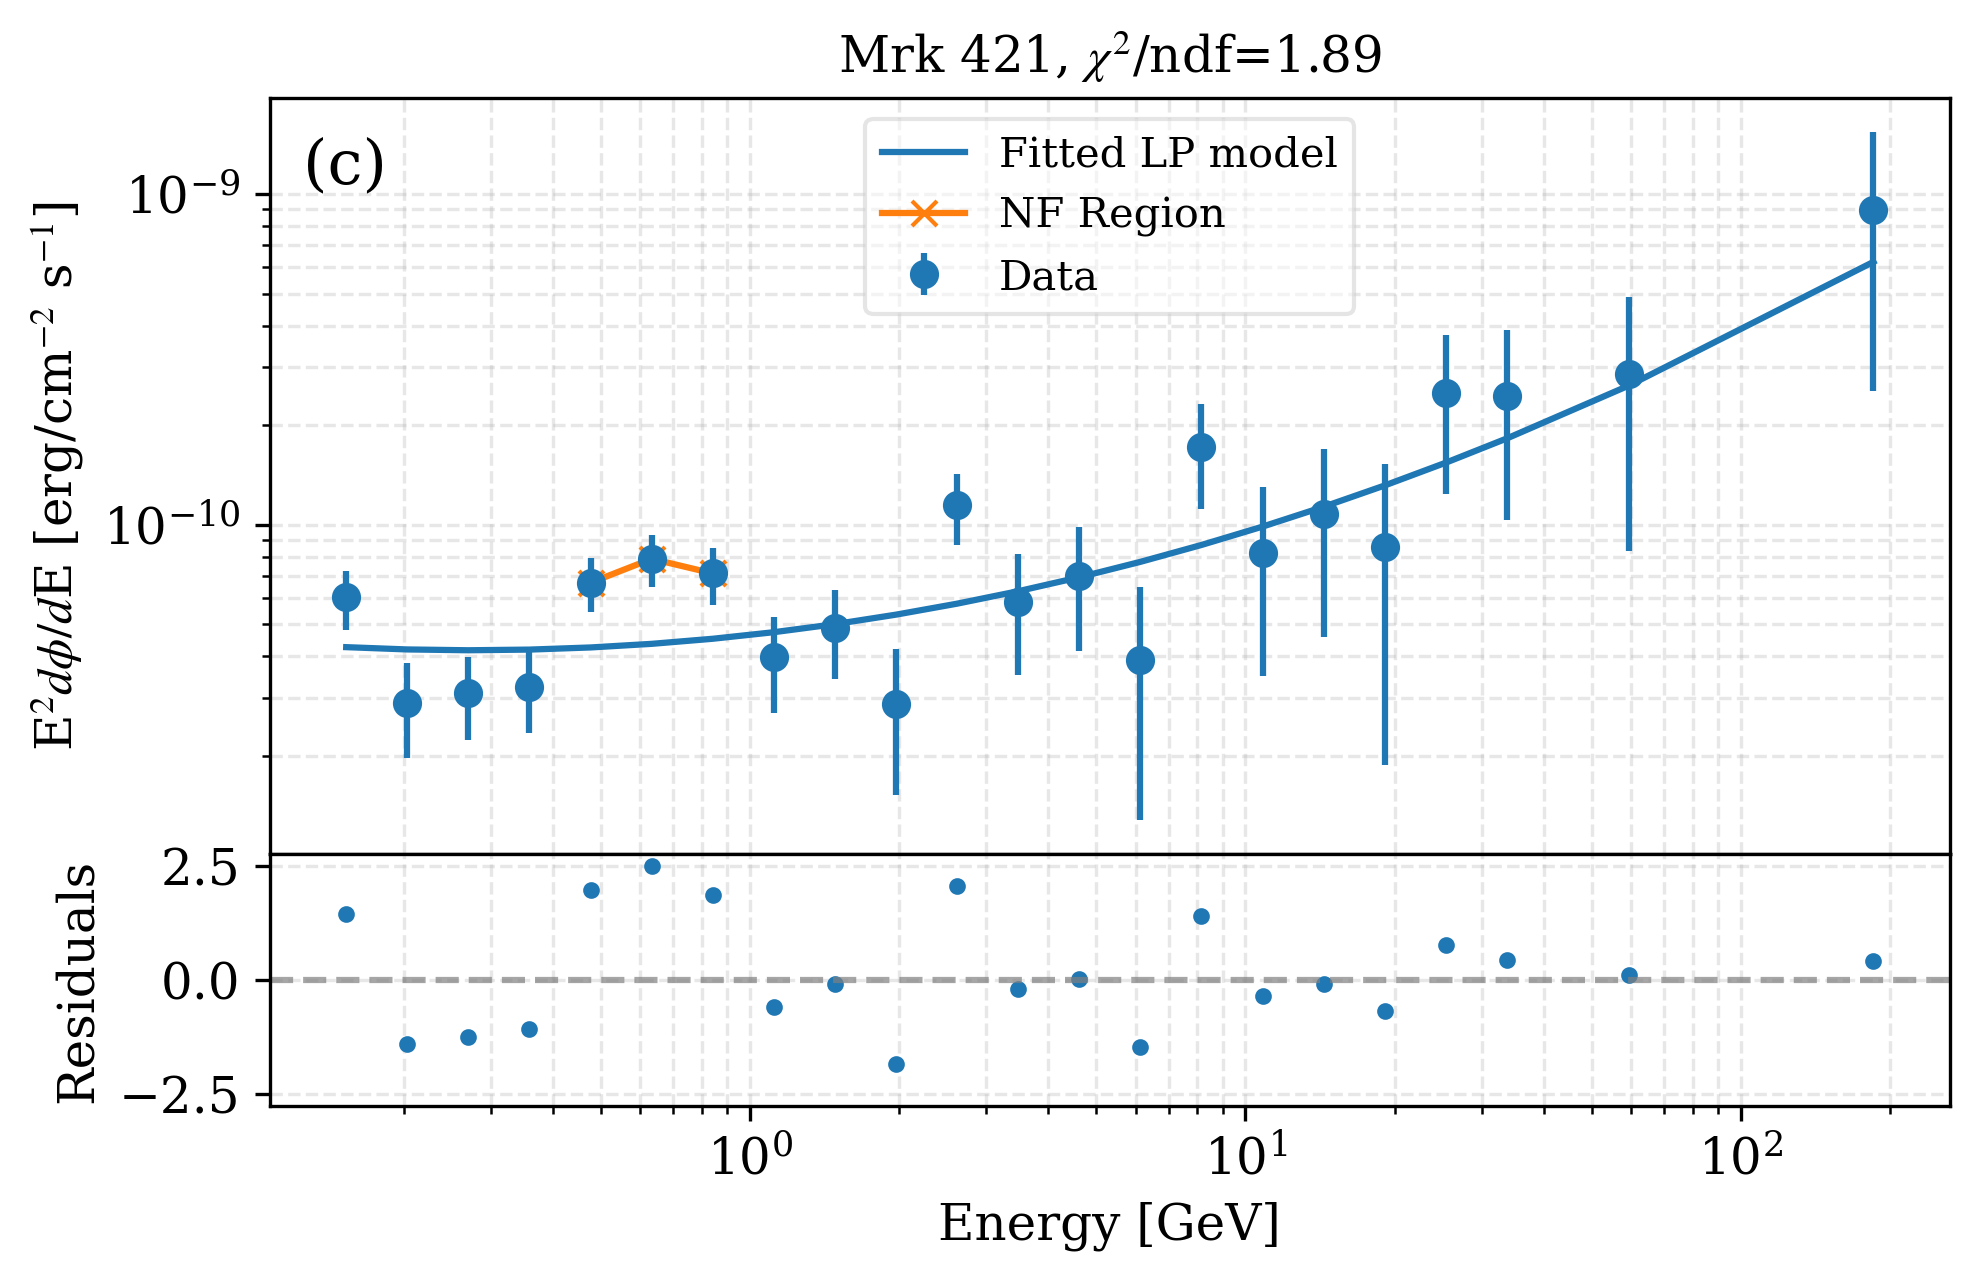

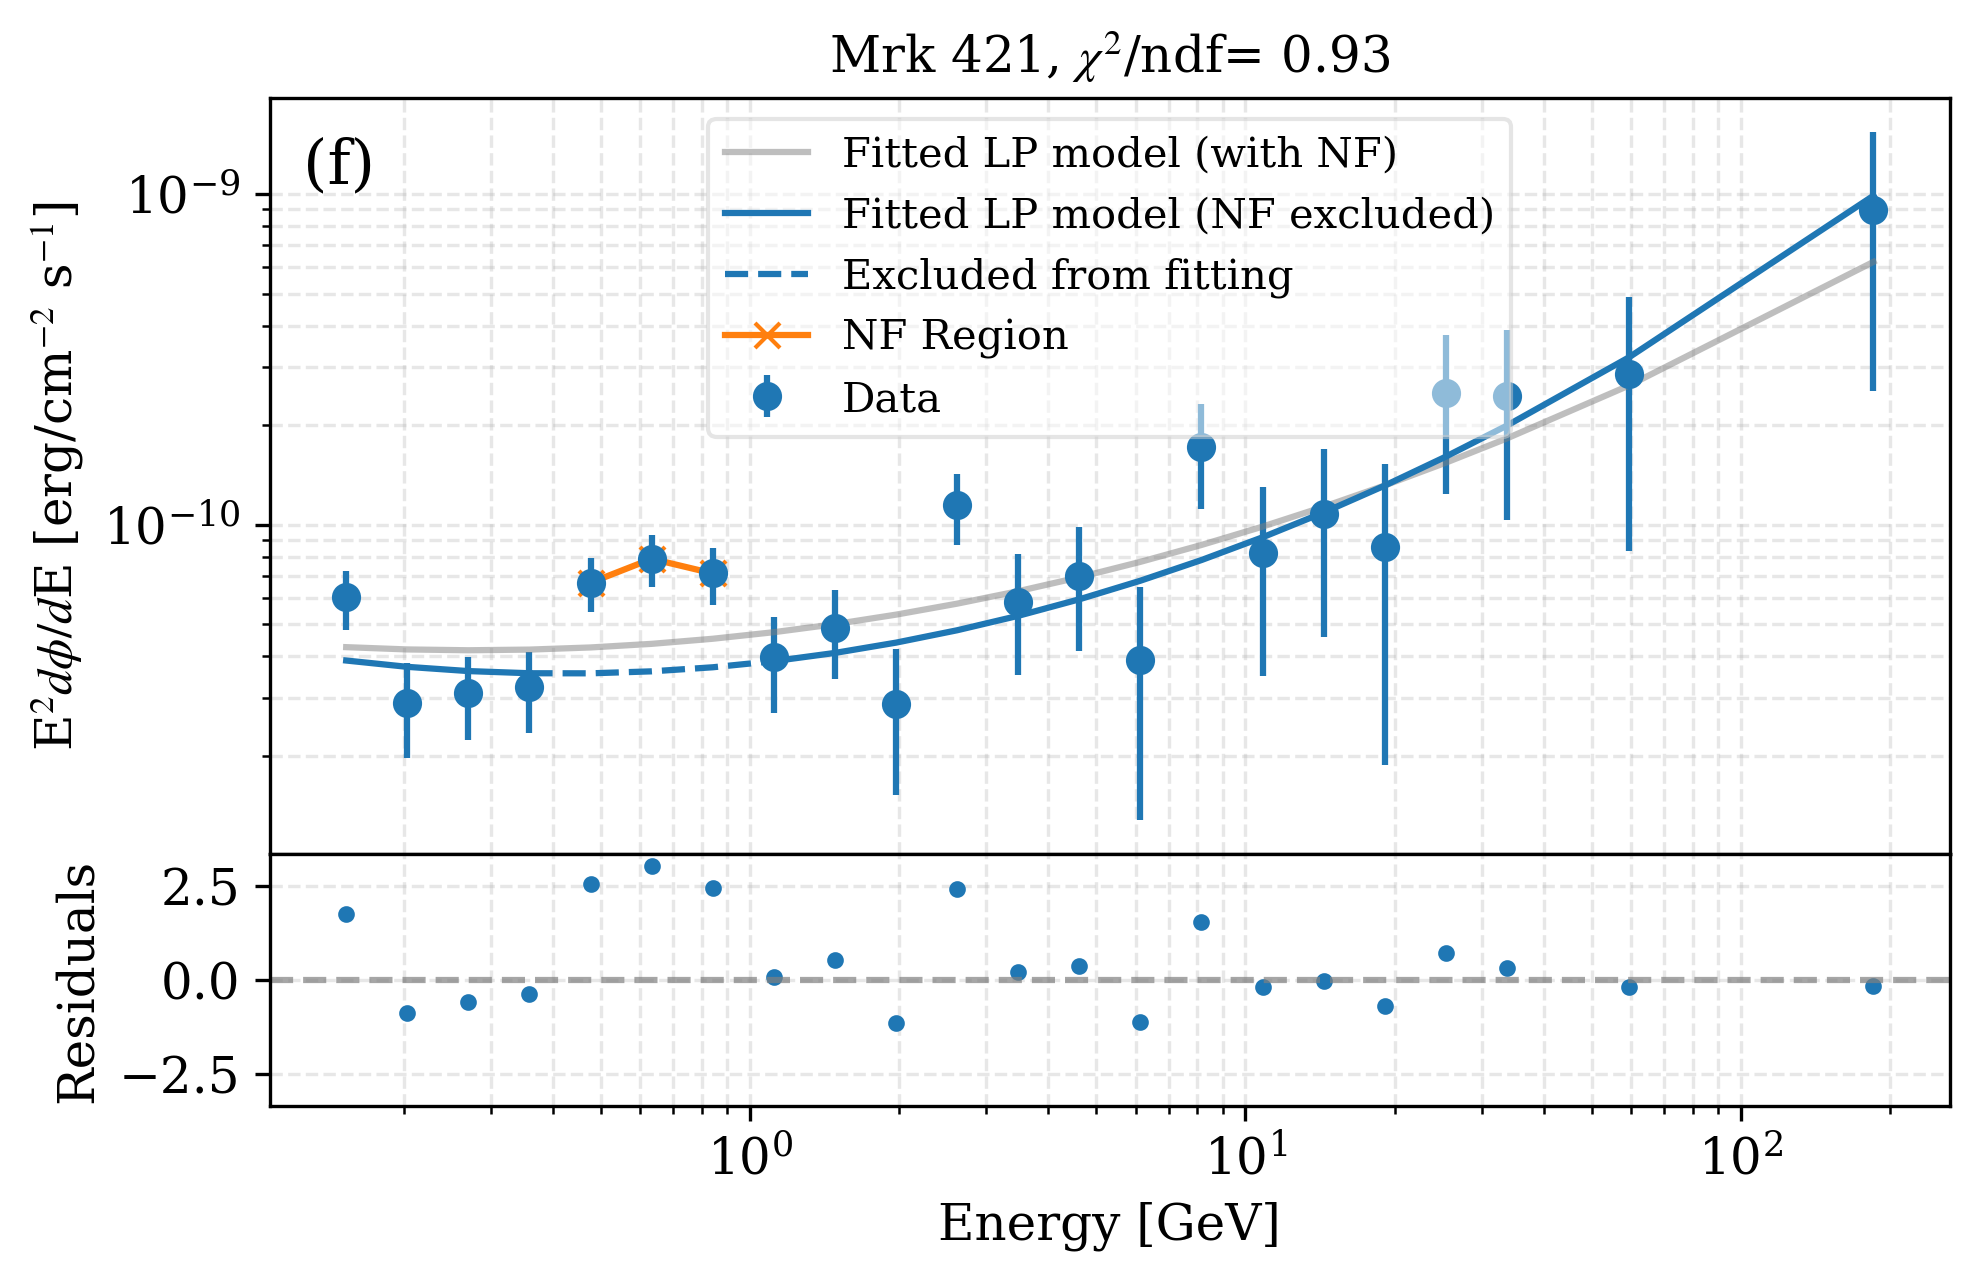

In [474]:
# dict_sourcename = get_dict_sourcenames()
n_brightest_sources = 1

array_data=[]
dict_sourcename = update_dict_sourcenames_for_drawing(dict_sourcename)

# NF type , Source       , Target MJD
#   1      PKS 0426-380  : MJD=57552
#   2      CTA 102       : MJD=57398
#   3      Mrk421        : MJD=59120
# Make a table for plotting the SEDs. The table will have the following columns:
# index, Source name, target MJD, 
# label for drawing SED with first fit, 
# label for drawing SED with second fit)
t_plot = Table(names=
               ['index', 'assoc name', 'targetMJD', 'labelA', 'labelB','leg_loc'], dtype=['i4', 'U20', 'f8', 'U10', 'U10', 'U10'])
t_plot.add_row((7,       'PKS0426-380', 57552,      '(a)', '(d)', 'lower left'))
t_plot.add_row((3,       'CTA102',      57398,      '(b)', '(e)', 'lower left'))
t_plot.add_row((1,       'Mrk421',      59120,      '(c)', '(f)', 'upper center'))

for drawtarget in t_plot:
  print(drawtarget)
  sourceinfo = dict_sourcename[drawtarget['index']]
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  draw_SED(filepath, drawtarget['targetMJD'], range_days=3, 
           sourcename=sourceinfo['assoc name'], sourcenamefordrawing=sourceinfo['assoc name for drawing'], suffix='14d', 
           figlabelA=drawtarget['labelA'],figlabelB=drawtarget['labelB'], leg_loc=drawtarget['leg_loc'])
